In [ ]:
# 3rd party imports
import ipywidgets as widgets
import matplotlib.pyplot as plt
import pandas as pd
import torch
from IPython.display import display
from torch.utils.data import DataLoader, TensorDataset, random_split


# Logging setup
import logging
logging.getLogger("matplotlib").setLevel(logging.WARNING)
logger = logging.getLogger()

# Local imports
from transportation_models.scripts.model_prototyping import *

# Definitions
data_filepath = "/Users/robstallman/Downloads/3hr_10pct_imputation/imputation_dataset.pt"

# Load dataset
data = torch.load(data_filepath)
logger.info(f"Loaded raw data from filepath: {data_filepath}")
X, y, meta = data["X"], data["y"], data["meta"]
dataset = TensorDataset(X.float(), y.float(), meta.float())

# Create training, validation, and testing splits
splits = [0.6, 0.2, 0.2]
train_set, val_set, test_set = random_split(
    dataset, lengths=splits, generator=torch.Generator().manual_seed(42)
)

# Set up DataLoader
val_loader = DataLoader(val_set, batch_size=len(val_set), shuffle=False)
xb, yb, meta_b = next(iter(val_loader))

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: Appending key for api.wandb.ai to your netrc file: /Users/robstallman/.netrc
wandb: Currently logged in as: robstallman3 (rost5691-cu-boulder) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
2026-04-09 15:01:37,505 - root - INFO - Loaded raw data from filepath: /Users/robstallman/Downloads/3hr_10pct_imputation/imputation_dataset.pt


In [55]:
def analyze_metrics(targets, epoch_results: dict[int, dict], metadata_key="meta", preds_key="preds", subtitle: str = None):
    """
    Args:
        targets: ground truth targets (shared across epochs)
        epoch_results: dict mapping epoch number -> {"preds": ..., "meta": ...}
        subtitle: optional plot subtitle
    """
    nbins = 50

    # Precompute plotting data per epoch
    epoch_data = {}
    for epoch, results in sorted(epoch_results.items()):
        predictions = results[preds_key]
        metadata = results[metadata_key]

        output_phys = PhysicsLoss.denormalize_targets(targets=predictions, station_meta=metadata)
        yb_phys = PhysicsLoss.denormalize_targets(targets=targets, station_meta=metadata)

        mask = meta_b[:, :, -1] == 0
        output_phys = output_phys[mask]
        yb_phys = yb_phys[mask]

        pred_flow = output_phys[:, 0]
        actual_flow = yb_phys[:, 0]
        pred_density = output_phys[:, 1]
        actual_density = yb_phys[:, 1]
        pred_speed = pred_flow / pred_density.clamp(min=1e-6)
        actual_speed = actual_flow / actual_density.clamp(min=1e-6)

        diff_flow = actual_flow - pred_flow
        diff_density = actual_density - pred_density
        diff_speed = actual_speed - pred_speed
        diff = torch.stack(tensors=(diff_flow, diff_density, diff_speed), dim=1)
        targ = torch.stack(tensors=(actual_flow, actual_density, actual_speed), dim=1)

        mae = diff.abs().mean(dim=0).tolist()
        mape = (diff.abs() / targ.abs()).mean(dim=0).tolist()
        mse = (diff ** 2).mean(dim=0).tolist()
        rmse = (diff ** 2).mean(dim=0).sqrt().tolist()

        unrealistic = pred_speed.abs() > 1e3
        pred_speed_to_plot = pred_speed[~unrealistic] if unrealistic.sum() > 0 else pred_speed
        n_dropped = unrealistic.sum().item()

        epoch_data[epoch] = {
            "actual_flow": actual_flow.numpy(),
            "pred_flow": pred_flow.numpy(),
            "actual_density": actual_density.numpy(),
            "pred_density": actual_density.numpy(),
            "actual_speed": actual_speed.numpy(),
            "pred_speed_to_plot": pred_speed_to_plot.numpy(),
            "n_dropped": n_dropped,
            "metrics": {
                "flow_mae": mae[0], "flow_mse": mse[0], "flow_rmse": rmse[0], "flow_mape": mape[0],
                "density_mae": mae[1], "density_mse": mse[1], "density_rmse": rmse[1], "density_mape": mape[1],
                "speed_mae": mae[2], "speed_mse": mse[2], "speed_rmse": rmse[2], "speed_mape": mape[2],
            },
        }

    sorted_epochs = sorted(epoch_data.keys())
    output = widgets.Output()

    def draw(epoch):
        output.clear_output(wait=True)
        with output:
            d = epoch_data[epoch]
            print("\n".join(f"{k}: {v:.4f}" for k, v in d["metrics"].items()))
            if d["n_dropped"] > 0:
                print(f"Dropping {d['n_dropped']} speed predictions from plot")

            fig, (ax1, ax2, ax3) = plt.subplots(nrows=1, ncols=3, figsize=(10, 10))
            ax1.hist(d["actual_flow"], bins=nbins, label="target")
            ax1.hist(d["pred_flow"], bins=nbins, label="prediction", alpha=0.5)
            ax1.set_xlabel("Flow [vehicles/hour-lane]")

            ax2.hist(d["actual_density"], bins=nbins, label="target")
            ax2.hist(d["pred_density"], bins=nbins, label="prediction", alpha=0.5)
            ax2.set_xlabel("Density [vehicles/mile-lane]")

            ax3.hist(d["actual_speed"], bins=nbins, label="target")
            ax3.hist(d["pred_speed_to_plot"], bins=nbins, label="prediction", alpha=0.5)
            ax3.set_xlabel("Speed [miles/hour]")
            ax3.legend(bbox_to_anchor=(1, 1))

            title = "Distribution of Predictions"
            if subtitle:
                title = f"{title}\n{subtitle}"
            plt.suptitle(f"{title}\nEpoch {epoch}")
            plt.tight_layout()
            plt.show()

    slider = widgets.IntSlider(
        value=sorted_epochs[0],
        min=sorted_epochs[0],
        max=sorted_epochs[-1],
        step=1,
        description="Epoch:",
        continuous_update=False,
    )
    slider.observe(lambda change: draw(change["new"]), names="value")
    display(slider, output)
    draw(sorted_epochs[0])

# Case #1: Pure Physics Loss
In this case, it seems that flow RMSE goes up and speed RMSE goes down

In [ ]:
epoch_results = {
    i: torch.load(f"/Users/robstallman/Downloads/quiet-sunset-77/val_predictions/epoch_{i:04d}.pt")
    for i in range(1, 12)
}
analyze_metrics(targets=yb, epoch_results=epoch_results, subtitle="Pure Physics Loss")

IntSlider(value=1, continuous_update=False, description='Epoch:', max=11, min=1)

Output()

# Case #2: Pure MSE loss

In [ ]:
epoch_results = {
    i: torch.load(f"/Users/robstallman/Downloads/unique-surf-74/val_predictions/epoch_{i:04d}.pt")
    for i in range(1, 12)
}
analyze_metrics(targets=yb, epoch_results=epoch_results, subtitle="Pure MSE Loss")

IntSlider(value=1, continuous_update=False, description='Epoch:', max=11, min=1)

Output()

# Case #3: Even Split

In [58]:
epoch_results = {
    i: torch.load(f"/Users/robstallman/Downloads/rosy-puddle-78/val_predictions/epoch_{i:04d}.pt")
    for i in range(1, 12)
}
analyze_metrics(targets=yb, epoch_results=epoch_results, subtitle="50/50 Physics/MSE")

IntSlider(value=1, continuous_update=False, description='Epoch:', max=11, min=1)

Output()

# Speed Metrics
We do pretty well with flow and density, but speed is so bad.
Let's look into what's causing that.

In [30]:
preds = epoch_results[11]['preds']
mask = meta_b[:, :, -1] == 0

preds_phys = PhysicsLoss.denormalize_targets(preds, meta_b)
targs_phys = PhysicsLoss.denormalize_targets(yb, meta_b)
preds_phys = preds_phys[mask]
targs_phys = targs_phys[mask]

flow_targ = targs_phys[:, 0]
density_targ = targs_phys[:, 1]
speed_targ = flow_targ / density_targ
flow_pred = preds_phys[:, 0]
density_pred = targs_phys[:, 1]
speed_pred = flow_pred / density_pred

print(f"Maximum speed (prediction): {speed_pred.max()}")
print(f"Maximum speed (actual): {speed_targ.max()}")
print(f"Number of times that density is zero when flow is not: {((density_targ == 0) != (flow_targ == 0)).sum()}")

Maximum speed (prediction): inf
Maximum speed (actual): nan
Number of times that density is zero when flow is not: 0


Alright, infinite speed predictions are definitely no good.

We're calculating speed by reversing the equation we used to calculate density:

$\rho = \frac{q}{v}$

Notice that we don't have the same problem in the actual speed when we calculate it in the same way. That's because whenever the density is zero in the data, the flow is by definition also zero, so our speed calculation produces nan in this case. 

For our predictions, the flow may be nonzero even when the density is zero, so we don't have the same guarantee and thus it's possible to get infinitely large speed predictions.

Let's look into the ground truth speed data and see what those measurements look like when the flow is zero.

In [ ]:
raw_data = pd.read_csv("/Users/robstallman/Downloads/3hr_10pct_imputation/data_long_unprocessed.csv")
raw_data.head()

,timestamp,Station ID,pct_observed,total_flow_[veh/5-min],avg_speed_[mph],Lanes,Type,Abs PM,Length,capacity,free_flow_speed,congestion_wave_speed,critical_density
0,2022-01-01 00:00:00,400409.0,0.0,162.0,69.2,4,Mainline,13.28,0.28,1664.051254,59.708524,1.538247,27.869576
1,2022-01-01 00:05:00,400409.0,0.0,159.0,68.9,4,Mainline,13.28,0.28,1664.051254,59.708524,1.538247,27.869576
2,2022-01-01 00:10:00,400409.0,0.0,155.0,68.9,4,Mainline,13.28,0.28,1664.051254,59.708524,1.538247,27.869576
3,2022-01-01 00:15:00,400409.0,0.0,150.0,68.8,4,Mainline,13.28,0.28,1664.051254,59.708524,1.538247,27.869576
4,2022-01-01 00:20:00,400409.0,0.0,142.0,68.7,4,Mainline,13.28,0.28,1664.051254,59.708524,1.538247,27.869576


<Axes: title={'center': 'Speed Distributions for flow = 0, pct_observed = 100'}, xlabel='Average Speed [miles/hour]', ylabel='Frequency'>

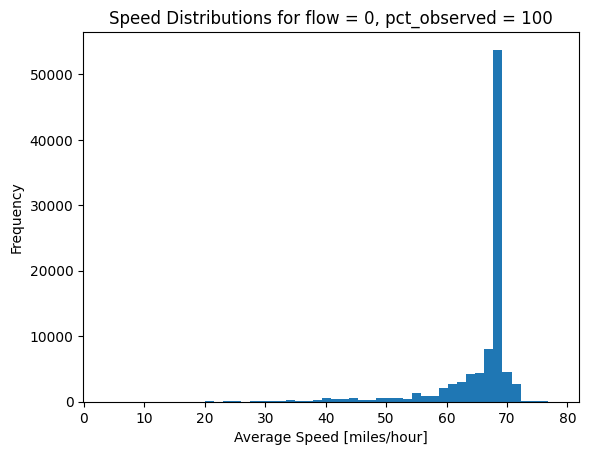

In [37]:
raw_data.loc[(raw_data['total_flow_[veh/5-min]'] == 0) & (raw_data['pct_observed'] >= 100.0), 'avg_speed_[mph]'].plot(kind='hist', bins=50, xlabel="Average Speed [miles/hour]", title="Speed Distributions for flow = 0, pct_observed = 100")

The speed is evidently non-zero, even though the measured flow is zero. 

This seems non-physical??

Let's go back to our predictions and see how we do when we filter out low-flow/low-density points

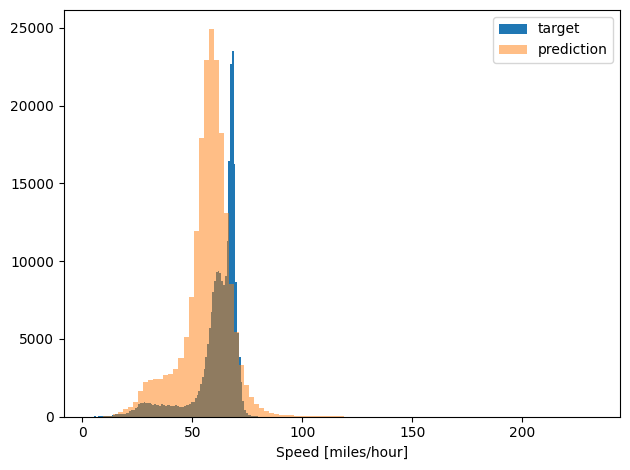

In [61]:
min_density = 5.0

density_mask = density_pred >= min_density
filtered_speed_pred = speed_pred[density_mask]

nbins=100
fig, ax = plt.subplots(nrows=1, ncols=1)
ax.hist(speed_targ, bins=nbins, label="target")
ax.hist(filtered_speed_pred, bins=nbins, label="prediction", alpha=0.5)
ax.set_xlabel("Speed [miles/hour]")
ax.legend(bbox_to_anchor=(1, 1))

plt.tight_layout()
plt.show()